In [5]:
#Packages to Import

#Numerical Elements
from numpy.linalg import norm
import numpy as np
from numpy import dot, array, transpose, diag

#Fun Progress Bar
from tqdm.notebook import tqdm

#Misc System (plotting etc)
import sys
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

import pickle
import warnings
warnings.filterwarnings('ignore')


#MCMC Sampliers and Related Utilities
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
%run ../MCMC_Sampliers.ipynb



#Plotting Libraries
import matplotlib.pyplot as plt
from numpy.linalg import norm



plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})


#Some Code to Compute measures of mixing

import numpy as np
from numpy.fft import rfft, irfft

def ess_OLDE(series: np.ndarray) -> float:
    """
    Effective Sample Size of a 1‑D NumPy array using the
    initial‑positive‑sequence rule (Geyer, 1992).

    Parameters
    ----------
    series : array_like, shape (N,)
        Time‑series values f(X₁),…,f(X_N).

    Returns
    -------
    ess : float
        Estimated effective sample size.
    """
    x = np.asarray(series, dtype=float)
    n = x.size
    x -= x.mean()

    # Autocovariances via FFT: O(N log N)
    fft = rfft(x, n=2*n)
    acov = irfft(fft * np.conjugate(fft))[:n] / n
    rho = acov / acov[0]           # normalised autocorrelation

    # Initial‑positive‑sequence truncation
    pos = np.where(rho[1:] > 0)[0]
    k = pos[-1] + 1 if pos.size else 0   # K = last positive lag

    ess = n / (1 + 2 * rho[1:k+1].sum())
    return ess


import numpy as np

def autocorr_func_1d(x):
    """Compute full autocorrelation function for 1D array x."""
    x = np.asarray(x)
    n = len(x)
    x -= x.mean()
    # unbiased variance
    c0 = np.dot(x, x) / n
    # full autocovariance
    acov = np.correlate(x, x, mode="full")[n-1:] / np.arange(n, 0, -1)
    return acov / c0

def ess(x, max_lag=None):
    """
    Effective Sample Size via initial positive sequence:
      ESS = N / [1 + 2 * sum_{k=1}^K rho_k]
    where K is the last lag before rho_k+rho_{k+1} < 0.
    """
    acf = autocorr_func_1d(x)
    N = len(x)
    # choose max_lag if not set
    if max_lag is None:
        max_lag = N//2
    rho = acf[1:max_lag]
    # find where successive pairs go negative
    K = max_lag
    for k in range(0, len(rho)-1, 2):
        if rho[k] + rho[k+1] < 0:
            K = k+1
            break
    tau = 1 + 2 * np.sum(rho[:K])
    return N / tau


def msjd(samples: np.ndarray) -> float:
    """
    Mean‑Squared Jumping Distance.

    Parameters
    ----------
    samples : array_like, shape (N, d)
        Markov‑chain states X₁,…,X_N.

    Returns
    -------
    msjd : float
        Average squared Euclidean distance between successive states.
    """
    diffs = np.diff(samples, axis=0)      # shape (N-1, d)
    return np.mean(np.sum(diffs**2, axis=1))


In [6]:
# Model Problem:  Statistical Inversion for the function f(x,y) = (x-a)^p y

#We consider the inverse problem 
#y = (x1-a)^p x2 + \eta  where \eta \sim N(0,\sigma^2)

#Specification of the forward problem (MM)
y = 6
a = .3
p = 1
sig = 1
fFn = lambda X : (X[0] - a)**(p)*X[1]
fFnStr = "(x1-" + str(a) + ")^" + str(p) + "x2"

NumParmsEx2 = 2

#LogLikihood function
PotEx2 = lambda X : (2* sig**2)**(-1) *(fFn(X) - y )**2

#Specifying the covariance
CovEVs = [3,2]
#Tth = 2*np.pi/9

#Rot = np.array([
#        [np.cos(Tth), -np.sin(Tth)],
#        [np.sin(Tth),  np.cos(Tth)]
#    ])
Diag = np.diag(CovEVs)

#CovEx2 = Rot.T @ Diag @ Rot

CovEx2 = Diag

  
MpCN Run
Total samples generated: 100000
rho Value: 0.1
p Value: 100
  


  0%|          | 0/100 [00:00<?, ?it/s]

Number of failed runs: 0
Percentage of Failure: 0.0
Number of MpCN Samples Now Available: 500999


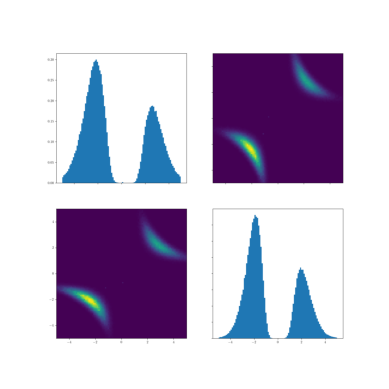

In [7]:
#Generate some test samples and visualization of the Model Problem

#Specifying File Location to Save Data 

FileNmBase= "Data/Inversion_Toy/"

paraStr = "y_" + str(y)+ "_sig_" + str(sig) + "_fn_" + fFnStr+ "_Cov_" + str(CovEx2)
histFileNm = FileNmBase + "HIST" + paraStr + ".png"
csvFileNm = FileNmBase + "DATA" + paraStr + ".csv"

#Generate Data Using MpCN

#NumRuns =  5000 #of total runs
#NumSamps = 10000 #samples per run

NumRuns =  100 #of total runs
NumSamps = 1000 #samples per run



rho = .1
pSmp = 100

print("  ")
print("MpCN Run")
print("Total samples generated: " + str(NumRuns*NumSamps))

print("rho Value: " + str(rho))
print("p Value: " + str(pSmp))
print("  ")


badtryNm = 0




#Make mpCN Run Saving to .csv ensuring NAN errors do not stop the process

q0 = np.random.normal(0,1,NumParmsEx2)
for curRnInx in tqdm(range(0,NumRuns)):
    try:
        cursamps = MpCN(q0,NumParmsEx2,CovEx2,rho,PotEx2,pSmp,NumSamps +1)
        q0 = cursamps[NumSamps]
        writeCSV(csvFileNm,cursamps)
    except OverflowError:
        badtryNm = badtryNm +1

print("Number of failed runs: " + str(badtryNm))
print("Percentage of Failure: " + str(badtryNm/NumRuns))

#Make Histogram

mpCNsampTr = readCSV(csvFileNm)
samLenmpCN = len(mpCNsampTr)
print("Number of MpCN Samples Now Available: " + str(samLenmpCN))

#Dimensions For Histogram Plot
R = 5
dr = .1

makeHistGrid(R, dr, mpCNsampTr, NumParmsEx2,histFileNm, True)

img = mpimg.imread(histFileNm)
plt.imshow(img)
plt.axis('off')  # Turn off the axes
plt.show()

  0%|          | 0/99 [00:00<?, ?it/s]

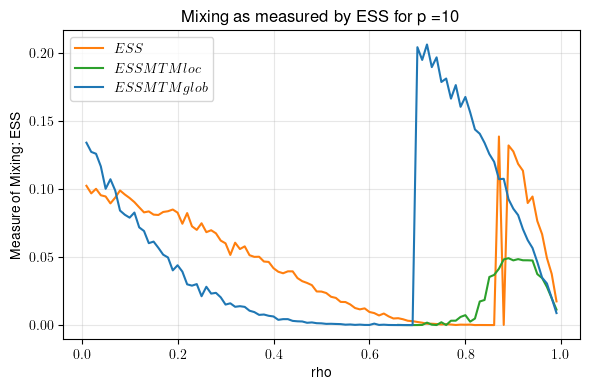

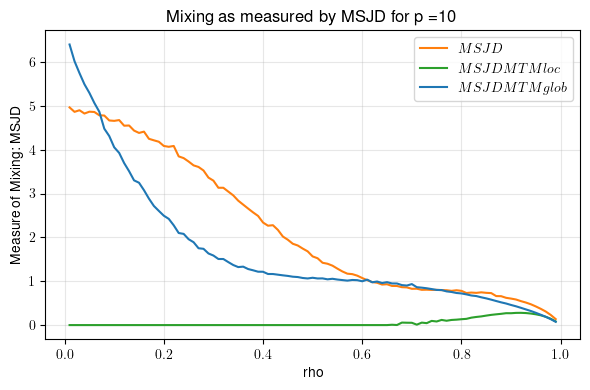

In [23]:
#Mixing as a function of rho
#Experiment 2

p10 = 10

NumRho = 100
delRho = 1/NumRho
burnIn = 5000
NumSamps = 100000
TotSamps = NumSamps-burnIn

ESSLstp10 = []
ESSLstp10loc = []
ESSLstp10glob = []
MSJDLstp10 = []
MSJDLstp10loc = []
MSJDLstp10glob = []
rhoLstp10 = []

#q0z = np.zeros(NumParmsEx2)
q0z = q0

rho = delRho
for curRnInx in tqdm(range(0,NumRho-1)):
    rhoLstp10.append(rho)
    curSamp = MpCN(q0z,NumParmsEx2,CovEx2,rho,PotEx2,p10,NumSamps)
    curSamploc = locMpCNMTM(q0z,NumParmsEx2,CovEx2,rho,PotEx2,p10,NumSamps)
    curSampglob = MpCNBBMTM(q0z,NumParmsEx2,CovEx2,rho,PotEx2,p10,NumSamps)
    ESSLstp10.append(ess(curSamp[burnIn:,0])/TotSamps)
    ESSLstp10loc.append(ess(curSamploc[burnIn:,0])/TotSamps)
    ESSLstp10glob.append(ess(curSampglob[burnIn:,0])/TotSamps)
    MSJDLstp10.append(msjd(curSamp[burnIn:]))
    MSJDLstp10loc.append(msjd(curSamploc[burnIn:]))
    MSJDLstp10glob.append(msjd(curSampglob[burnIn:]))
    rho = rho + delRho

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(rhoLstp10, ESSLstp10, linestyle="-", label=r"$ESS$", color="tab:orange")
ax.plot(rhoLstp10, ESSLstp10loc, linestyle="-", label=r"$ESSMTMloc$", color="tab:green")
ax.plot(rhoLstp10, ESSLstp10glob, linestyle="-",label=r"$ESSMTMglob$", color="tab:blue")

ax.set_xlabel("rho")
ax.set_ylabel(r"Measure of Mixing: ESS")
ax.set_title("Mixing as measured by ESS for p ="+str(p10))
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

plt.show()

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(rhoLstp10, MSJDLstp10, linestyle="-",label=r"$MSJD$", color="tab:orange")
ax.plot(rhoLstp10, MSJDLstp10loc, linestyle="-",label=r"$MSJDMTMloc$", color="tab:green")
ax.plot(rhoLstp10, MSJDLstp10glob, linestyle="-",label=r"$MSJDMTMglob$", color="tab:blue")

ax.set_xlabel("rho")
ax.set_ylabel(r"Measure of Mixing: MSJD")
ax.set_title("Mixing as measured by MSJD for p ="+str(p10))
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()


  0%|          | 0/99 [00:00<?, ?it/s]

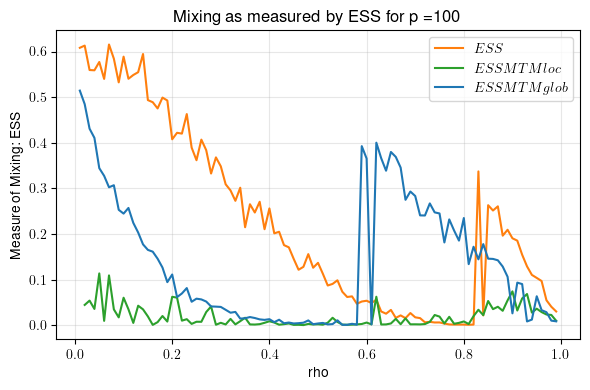

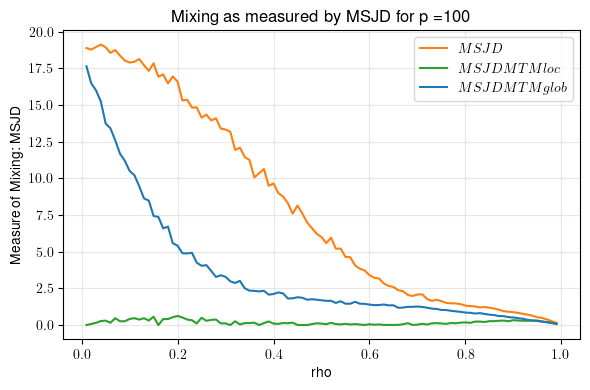

In [11]:
p100 = 100

NumRho = 100
delRho = 1/NumRho
burnIn = 1000
NumSamps = 5000
TotSamps = NumSamps-burnIn

ESSLstp100 = []
ESSLstp100loc = []
ESSLstp100glob = []
MSJDLstp100 = []
MSJDLstp100loc = []
MSJDLstp100glob = []
rhoLstp100 = []

q0z = np.zeros(NumParmsEx2)

rho = delRho
for curRnInx in tqdm(range(0,NumRho-1)):
    rhoLstp100.append(rho)
    curSamp = MpCN(q0z,NumParmsEx2,CovEx2,rho,PotEx2,p100,NumSamps)
    curSamploc = locMpCNMTM(q0z,NumParmsEx2,CovEx2,rho,PotEx2,p100,NumSamps)
    curSampglob = MpCNBBMTM(q0z,NumParmsEx2,CovEx2,rho,PotEx2,p100,NumSamps)
    ESSLstp100.append(ess(curSamp[burnIn:,0])/TotSamps)
    ESSLstp100loc.append(ess(curSamploc[burnIn:,0])/TotSamps)
    ESSLstp100glob.append(ess(curSampglob[burnIn:,0])/TotSamps)
    MSJDLstp100.append(msjd(curSamp[burnIn:]))
    MSJDLstp100loc.append(msjd(curSamploc[burnIn:]))
    MSJDLstp100glob.append(msjd(curSampglob[burnIn:]))
    rho = rho + delRho

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(rhoLstp100, ESSLstp100, linestyle="-", label=r"$ESS$", color="tab:orange")
ax.plot(rhoLstp100, ESSLstp100loc, linestyle="-", label=r"$ESSMTMloc$", color="tab:green")
ax.plot(rhoLstp100, ESSLstp100glob, linestyle="-",label=r"$ESSMTMglob$", color="tab:blue")

ax.set_xlabel("rho")
ax.set_ylabel(r"Measure of Mixing: ESS")
ax.set_title("Mixing as measured by ESS for p ="+str(p100))
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

plt.show()

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(rhoLstp100, MSJDLstp100, linestyle="-",label=r"$MSJD$", color="tab:orange")
ax.plot(rhoLstp100, MSJDLstp100loc, linestyle="-",label=r"$MSJDMTMloc$", color="tab:green")
ax.plot(rhoLstp100, MSJDLstp100glob, linestyle="-",label=r"$MSJDMTMglob$", color="tab:blue")

ax.set_xlabel("rho")
ax.set_ylabel(r"Measure of Mixing: MSJD")
ax.set_title("Mixing as measured by MSJD for p ="+str(p100))
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

  0%|          | 0/19 [00:00<?, ?it/s]

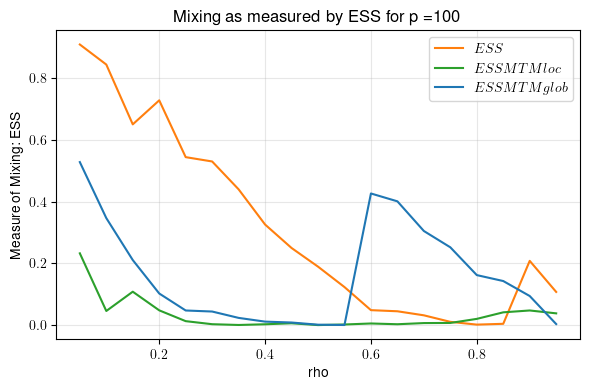

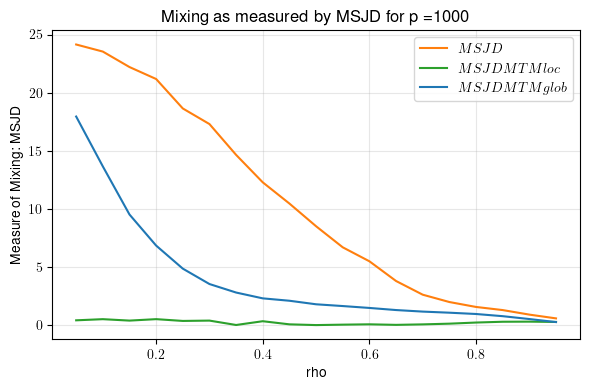

In [14]:
p1000 = 1000

NumRho = 20
delRho = 1/NumRho
burnIn = 1000
NumSamps = 5000
TotSamps = NumSamps-burnIn

ESSLstp1000 = []
ESSLstp1000loc = []
ESSLstp1000glob = []
MSJDLstp1000 = []
MSJDLstp1000loc = []
MSJDLstp1000glob = []
rhoLstp1000 = []

q0z = np.zeros(NumParmsEx2)

rho = delRho
for curRnInx in tqdm(range(0,NumRho-1)):
    rhoLstp1000.append(rho)
    curSamp = MpCN(q0z,NumParmsEx2,CovEx2,rho,PotEx2,p1000,NumSamps)
    curSamploc = locMpCNMTM(q0z,NumParmsEx2,CovEx2,rho,PotEx2,p1000,NumSamps)
    curSampglob = MpCNBBMTM(q0z,NumParmsEx2,CovEx2,rho,PotEx2,p1000,NumSamps)
    ESSLstp1000.append(ess(curSamp[burnIn:,0])/TotSamps)
    ESSLstp1000loc.append(ess(curSamploc[burnIn:,0])/TotSamps)
    ESSLstp1000glob.append(ess(curSampglob[burnIn:,0])/TotSamps)
    MSJDLstp1000.append(msjd(curSamp[burnIn:]))
    MSJDLstp1000loc.append(msjd(curSamploc[burnIn:]))
    MSJDLstp1000glob.append(msjd(curSampglob[burnIn:]))
    rho = rho + delRho

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(rhoLstp1000, ESSLstp1000, linestyle="-", label=r"$ESS$", color="tab:orange")
ax.plot(rhoLstp1000, ESSLstp1000loc, linestyle="-", label=r"$ESSMTMloc$", color="tab:green")
ax.plot(rhoLstp1000, ESSLstp1000glob, linestyle="-",label=r"$ESSMTMglob$", color="tab:blue")

ax.set_xlabel("rho")
ax.set_ylabel(r"Measure of Mixing: ESS")
ax.set_title("Mixing as measured by ESS for p ="+str(p100))
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

plt.show()

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(rhoLstp1000, MSJDLstp1000, linestyle="-",label=r"$MSJD$", color="tab:orange")
ax.plot(rhoLstp1000, MSJDLstp1000loc, linestyle="-",label=r"$MSJDMTMloc$", color="tab:green")
ax.plot(rhoLstp1000, MSJDLstp1000glob, linestyle="-",label=r"$MSJDMTMglob$", color="tab:blue")

ax.set_xlabel("rho")
ax.set_ylabel(r"Measure of Mixing: MSJD")
ax.set_title("Mixing as measured by MSJD for p ="+str(p1000))
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

  0%|          | 0/19 [00:00<?, ?it/s]

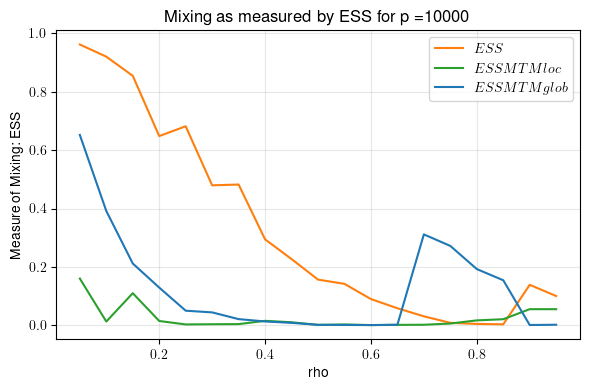

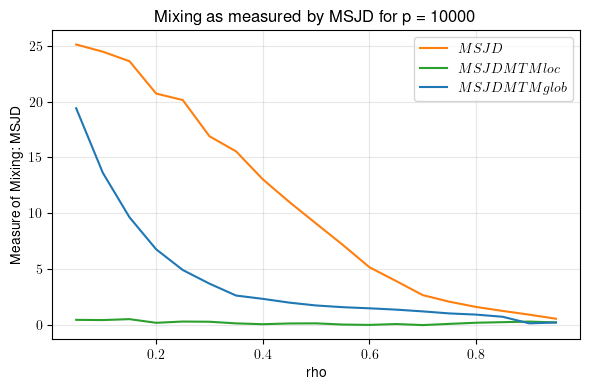

In [17]:
p10000 = 10000

NumRho = 20
delRho = 1/NumRho
burnIn = 1000
NumSamps = 5000
TotSamps = NumSamps-burnIn

ESSLstp10000 = []
ESSLstp10000loc = []
ESSLstp10000glob = []
MSJDLstp10000 = []
MSJDLstp10000loc = []
MSJDLstp10000glob = []
rhoLstp10000 = []

q0z = np.zeros(NumParmsEx2)

rho = delRho
for curRnInx in tqdm(range(0,NumRho-1)):
    rhoLstp10000.append(rho)
    curSamp = MpCN(q0z,NumParmsEx2,CovEx2,rho,PotEx2,p10000,NumSamps)
    curSamploc = locMpCNMTM(q0z,NumParmsEx2,CovEx2,rho,PotEx2,p10000,NumSamps)
    curSampglob = MpCNBBMTM(q0z,NumParmsEx2,CovEx2,rho,PotEx2,p10000,NumSamps)
    ESSLstp10000.append(ess(curSamp[burnIn:,0])/TotSamps)
    ESSLstp10000loc.append(ess(curSamploc[burnIn:,0])/TotSamps)
    ESSLstp10000glob.append(ess(curSampglob[burnIn:,0])/TotSamps)
    MSJDLstp10000.append(msjd(curSamp[burnIn:]))
    MSJDLstp10000loc.append(msjd(curSamploc[burnIn:]))
    MSJDLstp10000glob.append(msjd(curSampglob[burnIn:]))
    rho = rho + delRho

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(rhoLstp10000, ESSLstp10000, linestyle="-", label=r"$ESS$", color="tab:orange")
ax.plot(rhoLstp10000, ESSLstp10000loc, linestyle="-", label=r"$ESSMTMloc$", color="tab:green")
ax.plot(rhoLstp10000, ESSLstp10000glob, linestyle="-",label=r"$ESSMTMglob$", color="tab:blue")

ax.set_xlabel("rho")
ax.set_ylabel(r"Measure of Mixing: ESS")
ax.set_title("Mixing as measured by ESS for p ="+str(p10000))
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

plt.show()

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(rhoLstp10000, MSJDLstp10000, linestyle="-",label=r"$MSJD$", color="tab:orange")
ax.plot(rhoLstp10000, MSJDLstp10000loc, linestyle="-",label=r"$MSJDMTMloc$", color="tab:green")
ax.plot(rhoLstp10000, MSJDLstp10000glob, linestyle="-",label=r"$MSJDMTMglob$", color="tab:blue")

ax.set_xlabel("rho")
ax.set_ylabel(r"Measure of Mixing: MSJD")
ax.set_title("Mixing as measured by MSJD for p = " + str(p10000))
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
#Mixing as a function of rho
#Experiment 2

p10 = 10

NumRho = 500
delRho = 1/NumRho
burnIn = 5000
NumSamps =500000
TotSamps = NumSamps-burnIn

ESSLstp10 = []
ESSLstp10loc = []
ESSLstp10glob = []
MSJDLstp10 = []
MSJDLstp10loc = []
MSJDLstp10glob = []
rhoLstp10 = []

#q0z = np.zeros(NumParmsEx2)
q0z = q0

rho = delRho
for curRnInx in tqdm(range(0,NumRho-1)):
    rhoLstp10.append(rho)
    curSamp = MpCN(q0z,NumParmsEx2,CovEx2,rho,PotEx2,p10,NumSamps)
    curSamploc = locMpCNMTM(q0z,NumParmsEx2,CovEx2,rho,PotEx2,p10,NumSamps)
    curSampglob = MpCNBBMTM(q0z,NumParmsEx2,CovEx2,rho,PotEx2,p10,NumSamps)
    ESSLstp10.append(ess(curSamp[burnIn:,0])/TotSamps)
    ESSLstp10loc.append(ess(curSamploc[burnIn:,0])/TotSamps)
    ESSLstp10glob.append(ess(curSampglob[burnIn:,0])/TotSamps)
    MSJDLstp10.append(msjd(curSamp[burnIn:]))
    MSJDLstp10loc.append(msjd(curSamploc[burnIn:]))
    MSJDLstp10glob.append(msjd(curSampglob[burnIn:]))
    rho = rho + delRho

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(rhoLstp10, ESSLstp10, linestyle="-", label=r"$ESS$", color="tab:orange")
ax.plot(rhoLstp10, ESSLstp10loc, linestyle="-", label=r"$ESSMTMloc$", color="tab:green")
ax.plot(rhoLstp10, ESSLstp10glob, linestyle="-",label=r"$ESSMTMglob$", color="tab:blue")

ax.set_xlabel("rho")
ax.set_ylabel(r"Measure of Mixing: ESS")
ax.set_title("Mixing as measured by ESS for p ="+str(p10))
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

plt.show()

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(rhoLstp10, MSJDLstp10, linestyle="-",label=r"$MSJD$", color="tab:orange")
ax.plot(rhoLstp10, MSJDLstp10loc, linestyle="-",label=r"$MSJDMTMloc$", color="tab:green")
ax.plot(rhoLstp10, MSJDLstp10glob, linestyle="-",label=r"$MSJDMTMglob$", color="tab:blue")

ax.set_xlabel("rho")
ax.set_ylabel(r"Measure of Mixing: MSJD")
ax.set_title("Mixing as measured by MSJD for p ="+str(p10))
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

  0%|          | 0/499 [00:00<?, ?it/s]